In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report)
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("../results", exist_ok=True)


columns = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins", "logged_in",
    "num_compromised", "root_shell", "su_attempted", "num_root", "num_file_creations",
    "num_shells", "num_access_files", "num_outbound_cmds", "is_host_login",
    "is_guest_login", "count", "srv_count", "serror_rate", "srv_serror_rate",
    "rerror_rate", "srv_rerror_rate", "same_srv_rate", "diff_srv_rate",
    "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count",
    "dst_host_same_srv_rate", "dst_host_diff_srv_rate", "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate", "dst_host_serror_rate", "dst_host_srv_serror_rate",
    "dst_host_rerror_rate", "dst_host_srv_rerror_rate", "label", "difficulty"
]


train_df = pd.read_csv("../data/KDDTrain+.txt", names=columns)
test_df = pd.read_csv("../data/KDDTest+.txt", names=columns)


train_df = train_df.drop(columns=["difficulty"])
test_df = test_df.drop(columns=["difficulty"])


attack_map = {
    'normal': 0,
    'back': 1, 'land': 1, 'neptune': 1, 'pod': 1,
    'smurf': 1, 'teardrop': 1, 'mailbomb': 1,
    'apache2': 1, 'processtable': 1, 'udpstorm': 1,
    # Probe attacks
    'ipsweep': 2, 'nmap': 2, 'portsweep': 2,
    'satan': 2, 'mscan': 2, 'saint': 2,
    # R2L attacks
    'ftp_write': 3, 'guess_passwd': 3, 'imap': 3,
    'multihop': 3, 'phf': 3, 'spy': 3,
    'warezclient': 3, 'warezmaster': 3, 'sendmail': 3,
    'named': 3, 'snmpgetattack': 3, 'snmpguess': 3,
    'xlock': 3, 'xsnoop': 3, 'worm': 3,
    # U2R attacks
    'buffer_overflow': 4, 'loadmodule': 4, 'perl': 4,
    'rootkit': 4, 'httptunnel': 4, 'ps': 4,
    'sqlattack': 4, 'xterm': 4
}


train_df["label"] = train_df["label"].map(attack_map).fillna(0).astype(int)
test_df["label"] = test_df["label"].map(attack_map).fillna(0).astype(int)


class_names = {0: "Normal", 1: "DoS", 2: "Probe", 3: "R2L", 4: "U2R"}
print("=== Training Class Distribution ===")
for k, v in sorted(train_df["label"].value_counts().items()):
    print(f"  {class_names[k]} ({k}): {v:,}")

# --- Encode Categorical Columns ---
cat_cols = ["protocol_type", "service", "flag"]
encoder = LabelEncoder()
for col in cat_cols:
    train_df[col] = encoder.fit_transform(train_df[col])
    test_df[col] = encoder.fit_transform(test_df[col])

# --- Split Features and Labels ---
X_train = train_df.drop(columns=["label"])
y_train = train_df["label"]
X_test = test_df.drop(columns=["label"])
y_test = test_df["label"]

# --- Scale Features ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Apply Multi-Class SMOTE ---
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print("\n=== After SMOTE ===")
for k, v in sorted(pd.Series(y_train_sm).value_counts().items()):
    print(f"  {class_names[k]} ({k}): {v:,}")

print("\n Multi-class preprocessing complete!")

=== Training Class Distribution ===
  Normal (0): 67,343
  DoS (1): 45,927
  Probe (2): 11,656
  R2L (3): 995
  U2R (4): 52

=== After SMOTE ===
  Normal (0): 67,343
  DoS (1): 67,343
  Probe (2): 67,343
  R2L (3): 67,343
  U2R (4): 67,343

 Multi-class preprocessing complete!


Training Random Forest... (this may take 2-3 minutes)

===== Random Forest Results =====
Accuracy:  0.7485
Precision: 0.7970
Recall:    0.7485
F1-Score:  0.7013

===== Per Class Report =====
              precision    recall  f1-score   support

      Normal       0.65      0.97      0.78      9711
         DoS       0.96      0.76      0.85      7458
       Probe       0.85      0.72      0.78      2421
         R2L       0.86      0.00      0.01      2754
         U2R       0.45      0.03      0.05       200

    accuracy                           0.75     22544
   macro avg       0.75      0.50      0.49     22544
weighted avg       0.80      0.75      0.70     22544



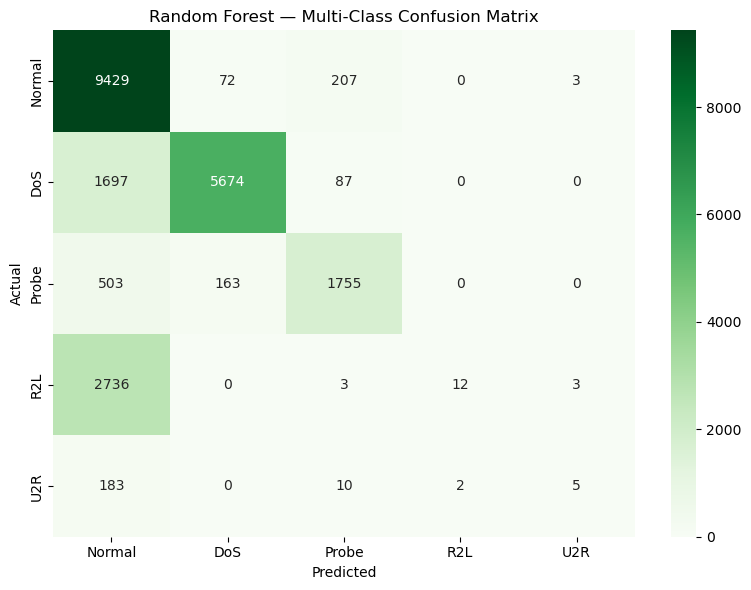

Confusion matrix saved!


In [2]:
from sklearn.ensemble import RandomForestClassifier

# --- Train ---
print("Training Random Forest.")
rf_model = RandomForestClassifier(
    random_state=42,
    class_weight="balanced",
    n_estimators=100,
    n_jobs=-1  # uses all CPU cores to speed up training
)
rf_model.fit(X_train_sm, y_train_sm)

rf_preds = rf_model.predict(X_test_scaled)

rf_proba = rf_model.predict_proba(X_test_scaled)

# --- Overall Metrics ---
print("\n===== Random Forest Results =====")
print(f"Accuracy:  {accuracy_score(y_test, rf_preds):.4f}")
print(f"Precision: {precision_score(y_test, rf_preds, average='weighted'):.4f}")
print(f"Recall:    {recall_score(y_test, rf_preds, average='weighted'):.4f}")
print(f"F1-Score:  {f1_score(y_test, rf_preds, average='weighted'):.4f}")

# --- Per Class Report ---
print("\n===== Per Class Report =====")
print(classification_report(y_test, rf_preds,
      target_names=["Normal", "DoS", "Probe", "R2L", "U2R"]))

# --- Confusion Matrix ---
cm_rf = confusion_matrix(y_test, rf_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Normal", "DoS", "Probe", "R2L", "U2R"],
            yticklabels=["Normal", "DoS", "Probe", "R2L", "U2R"])
plt.title("Random Forest — Multi-Class Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("../results/rf_confusion_matrix.png")
plt.show()
print("Confusion matrix saved!")

In [ ]:
%pip install tensorflow
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
import numpy as np


num_classes = 5
y_train_cat = to_categorical(y_train_sm, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

model = Sequential([
    # Input layer
    Dense(256, activation='relu', input_shape=(X_train_sm.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),

    # Hidden layer 1
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    # Hidden layer 2
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    # Hidden layer 3
    Dense(32, activation='relu'),
    Dropout(0.2),

    # Output layer
    # We convert our outputs into prob.
    Dense(num_classes, activation='softmax')
])

# --- Compile ---
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.51.0 requires protobuf<7,>=3.20, but you have protobuf 7.34.1 which is incompatible.


   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 2.6/351.2 MB 12.5 MB/s eta 0:00:28
    --------------------------------------- 5.8/351.2 MB 12.6 MB/s eta 0:00:28
    --------------------------------------- 8.7/351.2 MB 12.6 MB/s eta 0:00:28
   - -------------------------------------- 11.5/351.2 MB 12.6 MB/s eta 0:00:27
   - -------------------------------------- 14.4/351.2 MB 12.6 MB/s eta 0:00:27
   -- ------------------------------------- 18.6/351.2 MB 11.2 MB/s eta 0:00:30
   -- ------------------------------------- 21.8/351.2 MB 11.3 MB/s eta 0:00:30
   -- ------------------------------------- 24.6/351.2 MB 11.5 MB/s eta 0:00:29
   --- ------------------------------------ 29.9/351.2 MB 11.1 MB/s eta 0:00:29
   --- ------------------------------------ 32.5/351.2 MB 11.2 MB/s eta 0:00:29
   ---- ----------------------------------- 35.4/351.2 MB 11.3 MB/s eta 0:00:28
   ---- ----------------------------------- 39.1/351

c:\Users\USER\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        10,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,941 (218.52 KB)

 Trainable params: 55,045 (215.02 KB)

 Non-trainable params: 896 (3.50 KB)

In [5]:
# --- Callbacks ---
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

# --- Train ---
print("Training DNN...")
history = model.fit(
    X_train_sm, y_train_cat,
    epochs=50,
    batch_size=256,
    validation_split=0.1,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print("\n DNN Training complete!")

Training DNN...
Epoch 1/50
1184/1184 ━━━━━━━━━━━━━━━━━━━━ 45s 18ms/step - accuracy: 0.9517 - loss: 0.1489 - val_accuracy: 0.9943 - val_loss: 0.0502 - learning_rate: 0.0010
Epoch 2/50
1184/1184 ━━━━━━━━━━━━━━━━━━━━ 44s 20ms/step - accuracy: 0.9780 - loss: 0.0644 - val_accuracy: 0.9975 - val_loss: 0.0594 - learning_rate: 0.0010
Epoch 3/50
1184/1184 ━━━━━━━━━━━━━━━━━━━━ 21s 18ms/step - accuracy: 0.9818 - loss: 0.0528 - val_accuracy: 1.0000 - val_loss: 0.0396 - learning_rate: 0.0010
Epoch 4/50
1184/1184 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - accuracy: 0.9839 - loss: 0.0454 - val_accuracy: 0.9966 - val_loss: 0.0631 - learning_rate: 0.0010
Epoch 5/50
1184/1184 ━━━━━━━━━━━━━━━━━━━━ 40s 17ms/step - accuracy: 0.9851 - loss: 0.0415 - val_accuracy: 1.0000 - val_loss: 0.0233 - learning_rate: 0.0010
Epoch 6/50
1184/1184 ━━━━━━━━━━━━━━━━━━━━ 22s 17ms/step - accuracy: 0.9861 - loss: 0.0381 - val_accuracy: 1.0000 - val_loss: 0.0438 - learning_rate: 0.0010
Epoch 7/50
1184/1184 ━━━━━━━━━━━━━━━━━━━━ 22s 19

705/705 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step
Average Prediction Confidence: 0.9781
Min Confidence: 0.3812
Max Confidence: 1.0000

===== DNN Results =====
Accuracy:  0.7562
Precision: 0.8023
Recall:    0.7562
F1-Score:  0.7286

===== Per Class Report =====
              precision    recall  f1-score   support

      Normal       0.68      0.97      0.80      9711
         DoS       0.94      0.77      0.84      7458
       Probe       0.76      0.58      0.66      2421
         R2L       0.96      0.16      0.27      2754
         U2R       0.17      0.14      0.15       200

    accuracy                           0.76     22544
   macro avg       0.70      0.52      0.55     22544
weighted avg       0.80      0.76      0.73     22544



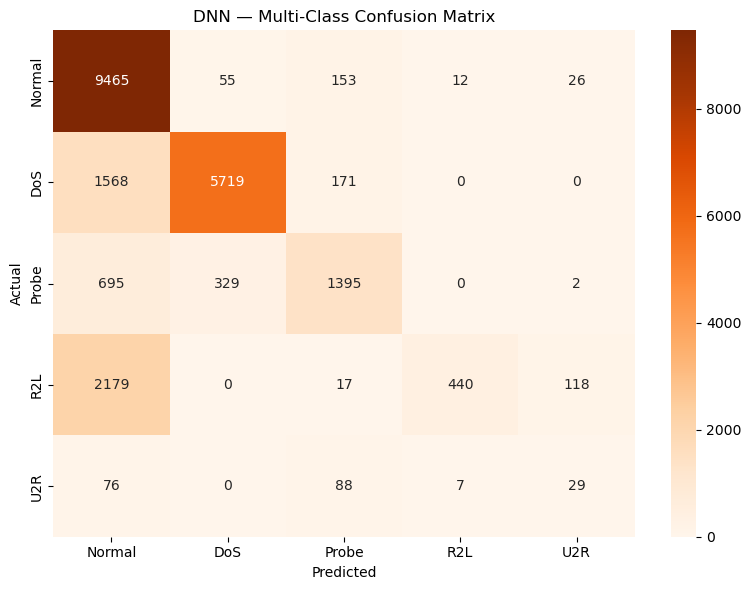

DNN confusion matrix saved!


In [6]:
# --- Predictions ---
dnn_proba = model.predict(X_test_scaled)
dnn_preds = np.argmax(dnn_proba, axis=1)

# --- Confidence Scores ---
dnn_confidence = np.max(dnn_proba, axis=1)
print(f"Average Prediction Confidence: {dnn_confidence.mean():.4f}")
print(f"Min Confidence: {dnn_confidence.min():.4f}")
print(f"Max Confidence: {dnn_confidence.max():.4f}")

# --- Overall Metrics ---
print("\n===== DNN Results =====")
print(f"Accuracy:  {accuracy_score(y_test, dnn_preds):.4f}")
print(f"Precision: {precision_score(y_test, dnn_preds, average='weighted'):.4f}")
print(f"Recall:    {recall_score(y_test, dnn_preds, average='weighted'):.4f}")
print(f"F1-Score:  {f1_score(y_test, dnn_preds, average='weighted'):.4f}")

# --- Per Class Report ---
print("\n===== Per Class Report =====")
print(classification_report(y_test, dnn_preds,
      target_names=["Normal", "DoS", "Probe", "R2L", "U2R"]))

# --- Confusion Matrix ---
cm_dnn = confusion_matrix(y_test, dnn_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dnn, annot=True, fmt="d", cmap="Oranges",
            xticklabels=["Normal", "DoS", "Probe", "R2L", "U2R"],
            yticklabels=["Normal", "DoS", "Probe", "R2L", "U2R"])
plt.title("DNN — Multi-Class Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("../results/dnn_confusion_matrix.png")
plt.show()
print("DNN confusion matrix saved!")